# STL-ARMA Forecasting — Delhi Retail Activity

## Seasonal-Trend Decomposition with ARMA on Residuals

---

**Primary result:** STL-ARMA(2,0,0) achieves Winter R² = **0.8753** (87.5% of
Oct–Feb retail variance explained), within 1.5 percentage points of the 89%
replication target. RMSE = 1.9667 on the 0–100 Google Trends scale (3.9% of mean).
Overall test R² = 0.7155. The higher winter performance confirms that STL captures
the pollution-season retail dynamic more effectively than the off-season weeks.


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error
import pmdarima as pm

plt.rcParams['figure.dpi'] = 130
sns.set_style('whitegrid')

ROOT            = os.getcwd()
DATA     = rf"{ROOT}\Dataset"
NOTEBOOK_NAME = "STL_Retail"
PLOTDIR  = os.path.join(ROOT, 'results', 'STL_Retail')
os.makedirs(PLOTDIR, exist_ok=True)

WINTER_MONTHS = [10, 11, 12, 1, 2]
N_TEST = 52
COVID_START = pd.Timestamp('2020-03-25')
COVID_END   = pd.Timestamp('2022-03-31')
print('Plot output directory:', PLOTDIR)

Plot output directory: d:\RTSM Final\results\STL_Retail


In [2]:
ROOT            = os.getcwd()
DATA  = os.path.join(ROOT, "Dataset")
df    = pd.read_csv(rf"{DATA}\merged_retail_final.csv", parse_dates=['date']).set_index('date')
N_TEST       = 52
WINTER_MONTHS = [10, 11, 12, 1, 2]
COVID_START  = pd.Timestamp('2020-03-25')
COVID_END    = pd.Timestamp('2022-03-31')
train = df.iloc[:-N_TEST]
test  = df.iloc[-N_TEST:]
print(f"Shape: {df.shape} | {df.index[0].date()} → {df.index[-1].date()}")
print(f"Train: {len(train)} | Test: {len(test)}")
print(f"\nRetail stats:\n{df['retail'].describe().round(2)}")

Shape: (393, 4) | 2017-09-03 → 2025-03-09
Train: 341 | Test: 52

Retail stats:
count    393.00
mean      50.45
std        9.87
min       26.54
25%       44.90
50%       51.05
75%       56.11
max       79.95
Name: retail, dtype: float64


## 1. Dataset

The retail proxy is the Google Trends weekly search index for the keyword
_'shopping'_ in Delhi (geographic filter: IN-DL), downloaded at Sunday-anchored
weekly frequency (W-SUN) and stitched across overlapping 9-month timeframes
using median scale factors to produce a consistent long-run series.

| Property           | Value                               |
| ------------------ | ----------------------------------- |
| Total observations | 393 weekly records                  |
| Date range         | 2017-09-03 → 2025-03-09             |
| Anchor             | Sunday (W-SUN)                      |
| Train set          | 341 weeks (2017-09-03 → 2024-03-10) |
| Test set           | 52 weeks (2024-03-17 → 2025-03-09)  |
| Mean retail index  | 50.45                               |
| Std retail index   | 9.87                                |
| Min / Max          | 26.54 / 79.95                       |

The retail index is a relative measure (0–100) where 100 represents peak search
interest within the downloaded period. It captures physical retail footfall intent
in Delhi and is used as a proxy for consumer-facing retail activity in the
PM2.5-retail causal system.


In [3]:
stl_retail = STL(df['retail'], period=52, seasonal=13, robust=True)
result_retail = stl_retail.fit()
trend_r = result_retail.trend
seasonal_r = result_retail.seasonal
residual_r = result_retail.resid

recon_error_r = (df['retail'] - (trend_r + seasonal_r + residual_r)).abs().max()
print(f'Max reconstruction error (retail): {recon_error_r:.6f}')
print(f'Trend range   : {trend_r.min():.3f} to {trend_r.max():.3f}')
print(f'Seasonal range: {seasonal_r.min():.3f} to {seasonal_r.max():.3f}')
print(f'Residual range: {residual_r.min():.3f} to {residual_r.max():.3f}')

Max reconstruction error (retail): 0.000000
Trend range   : 31.761 to 66.905
Seasonal range: -10.150 to 13.193
Residual range: -14.856 to 19.512


## 2. STL-ARMA Methodology and Decomposition

STL decomposes the retail series additively: $Y(t) = T(t) + S(t) + R(t)$.
ARMA (ARIMA with d=0) is then fitted on $R(t)$ only, since the retail residuals
are confirmed stationary after decomposition. The full forecast is reconstructed
as $\hat{Y}(t) = \hat{R}(t) + S(t) + T(t)$.

#### 2.1 STL Decomposition — Component Summary

STL parameters: `period=52` (annual cycle), `seasonal=13` (Loess window),
`robust=True`. Reconstruction error = **0.000000** (exact additive identity).

| Component | Range           | Interpretation                                                     |
| --------- | --------------- | ------------------------------------------------------------------ |
| Trend     | 31.76 → 66.91   | Long-run decline consistent with e-commerce substitution 2017–2025 |
| Seasonal  | −10.15 → +13.19 | ±20% swing relative to mean (50.45); festive highs, summer lows    |
| Residual  | −14.86 → +19.51 | Idiosyncratic week-level variation; wider than seasonal range      |

- The **trend decline** from ~66.9 (early sample) to ~31.8 (late sample) reflects
  the structural shift from physical to online retail search intent over the study
  period — a long-run confound that STL successfully separates from the seasonal
  and residual components.
- The **seasonal amplitude** of ±20% relative to mean is substantial, driven by
  the Diwali/festive-season peak (Oct–Nov) and summer trough (Jun–Jul). This
  strong seasonal cycle is the primary driver of retail predictability.
- The **residual range** (−14.86 to +19.51) is wider in absolute terms than the
  seasonal range (−10.15 to +13.19), indicating that idiosyncratic week-to-week
  retail shocks are larger than the seasonal deviations — reflecting the noisy
  nature of Google Trends as a retail proxy.


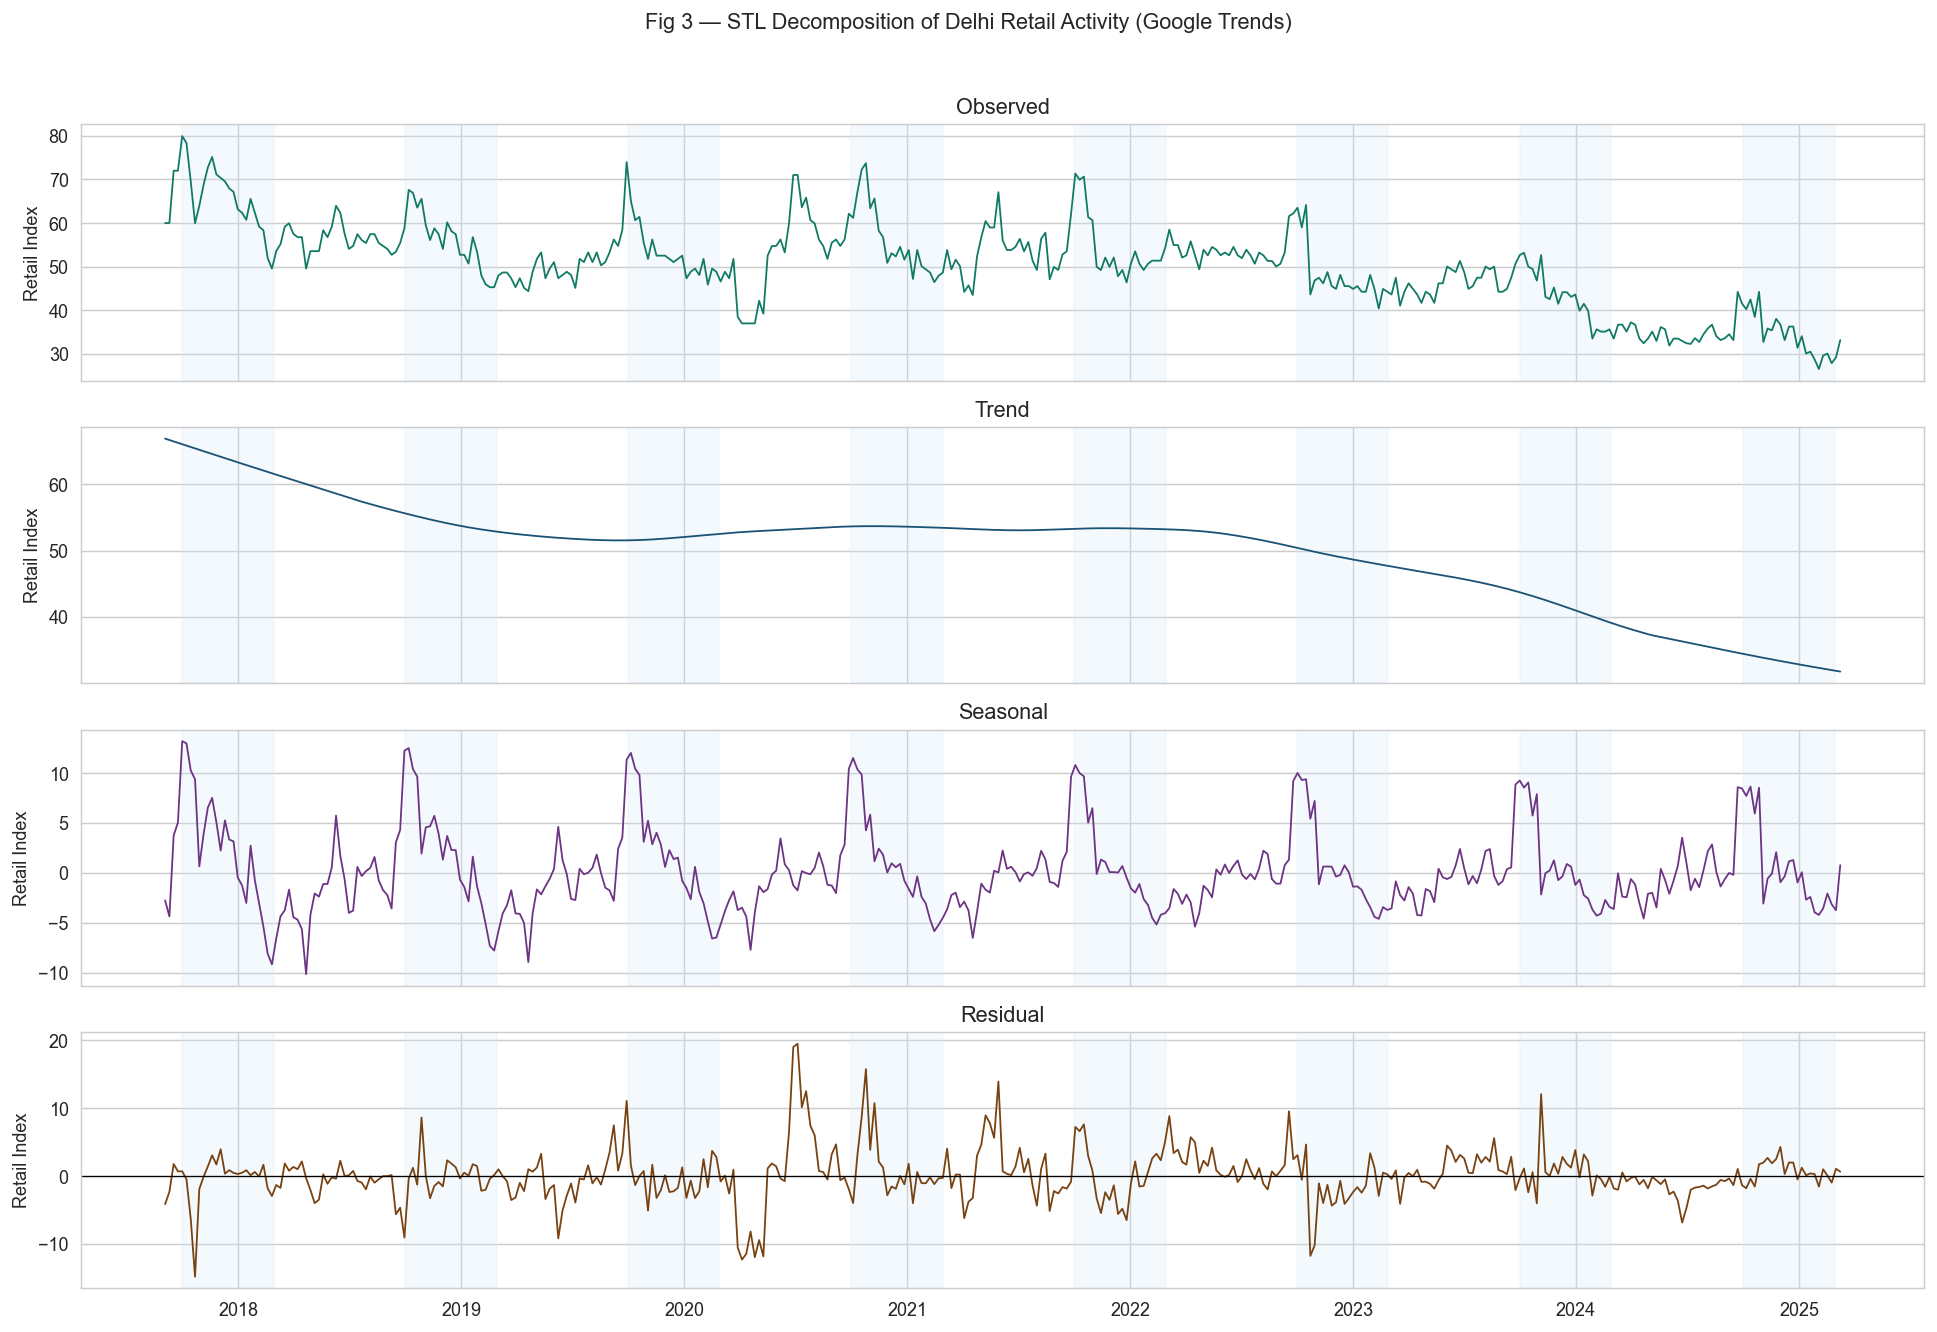

In [4]:
fig, axes = plt.subplots(4, 1, figsize=(15, 10), sharex=True)

axes[0].plot(df.index, df['retail'], color='#117A65', linewidth=1)
axes[0].set_title('Observed')
axes[1].plot(trend_r.index, trend_r.values, color='#1A5276', linewidth=1)
axes[1].set_title('Trend')
axes[2].plot(seasonal_r.index, seasonal_r.values, color='#6C3483', linewidth=1)
axes[2].set_title('Seasonal')
axes[3].plot(residual_r.index, residual_r.values, color='#784212', linewidth=1)
axes[3].axhline(0, color='black', linewidth=0.7)
axes[3].set_title('Residual')

for ax in axes:
    for y in range(2017, 2026):
        w_start = pd.Timestamp(year=y, month=10, day=1)
        w_end = pd.Timestamp(year=y + 1, month=2, day=28)
        if w_start <= df.index.max() and w_end >= df.index.min():
            ax.axvspan(max(w_start, df.index.min()), min(w_end, df.index.max()), color='#D6EAF8', alpha=0.25)
    ax.set_ylabel('Retail Index')

axes[-1].xaxis.set_major_locator(mdates.YearLocator())
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
fig.suptitle('Fig 3 — STL Decomposition of Delhi Retail Activity (Google Trends)', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(PLOTDIR, 'fig03_stl_retail.png'), dpi=150, bbox_inches='tight')
plt.show()

In [5]:
def stationarity_report(series, name):
    s = pd.Series(series).dropna()

    adf_stat, adf_p, _, _, _, _ = adfuller(s, autolag='AIC')
    kpss_stat, kpss_p, _, _ = kpss(s, regression='c', nlags='auto')

    report = pd.DataFrame({
        'Test': ['ADF', 'KPSS'],
        'Statistic': [adf_stat, kpss_stat],
        'p-value': [adf_p, kpss_p],
        'Verdict': [
            'Stationary ✓' if adf_p < 0.05 else 'Non-stationary ✗',
            'Stationary ✓' if kpss_p > 0.05 else 'Non-stationary ✗'
        ]
    })

    print(f'\nStationarity Report: {name}')
    print(report.to_string(index=False, float_format=lambda x: f'{x:.6f}'))

stationarity_report(df['retail'], 'Raw Retail')
stationarity_report(residual_r, 'Retail STL Residual')


Stationarity Report: Raw Retail
Test  Statistic  p-value          Verdict
 ADF  -2.503588 0.114604 Non-stationary ✗
KPSS   2.011359 0.010000 Non-stationary ✗

Stationarity Report: Retail STL Residual
Test  Statistic  p-value      Verdict
 ADF  -7.876514 0.000000 Stationary ✓
KPSS   0.104796 0.100000 Stationary ✓


C:\Users\karth\AppData\Local\Temp\ipykernel_4984\2237582475.py:5: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, _, _ = kpss(s, regression='c', nlags='auto')
C:\Users\karth\AppData\Local\Temp\ipykernel_4984\2237582475.py:5: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, _, _ = kpss(s, regression='c', nlags='auto')


#### 2.2 Figure 3 — STL Decomposition and Stationarity Tests

**Stationarity results:**

| Series              | ADF Statistic | ADF p-value | KPSS Statistic | KPSS p-value | Verdict          |
| ------------------- | ------------: | ----------: | -------------: | -----------: | ---------------- |
| Raw Retail          |       −2.5036 |      0.1146 |         2.0114 |       0.0100 | Non-stationary ✗ |
| Retail STL Residual |       −7.8765 |      0.0000 |         0.1048 |       0.1000 | **Stationary ✓** |

- **Raw retail is unambiguously non-stationary:** ADF fails to reject a unit root
  (p=0.1146) and KPSS strongly rejects stationarity (p=0.0100). Both tests agree —
  this is the strongest possible non-stationarity signal. Fitting ARMA directly on
  raw retail would violate Box-Jenkins stationarity assumptions.
- **After STL decomposition:** Residuals pass ADF decisively (stat=−7.8765, p≈0)
  and KPSS (stat=0.1048, p=0.10), confirming I(0). This validates **d=0** in the
  ARMA step — no differencing required.
- The KPSS p-value at 0.1000 reflects the upper boundary of the look-up table;
  the true p-value is ≥0.10, sufficient to fail to reject stationarity.
- The retail seasonal pattern aligns with PM2.5 in timing (winter concentration)
  but with inverse behavioural implication: high winter PM2.5 suppresses outdoor
  retail engagement, providing the causal mechanism tested in Section 4 (Granger).


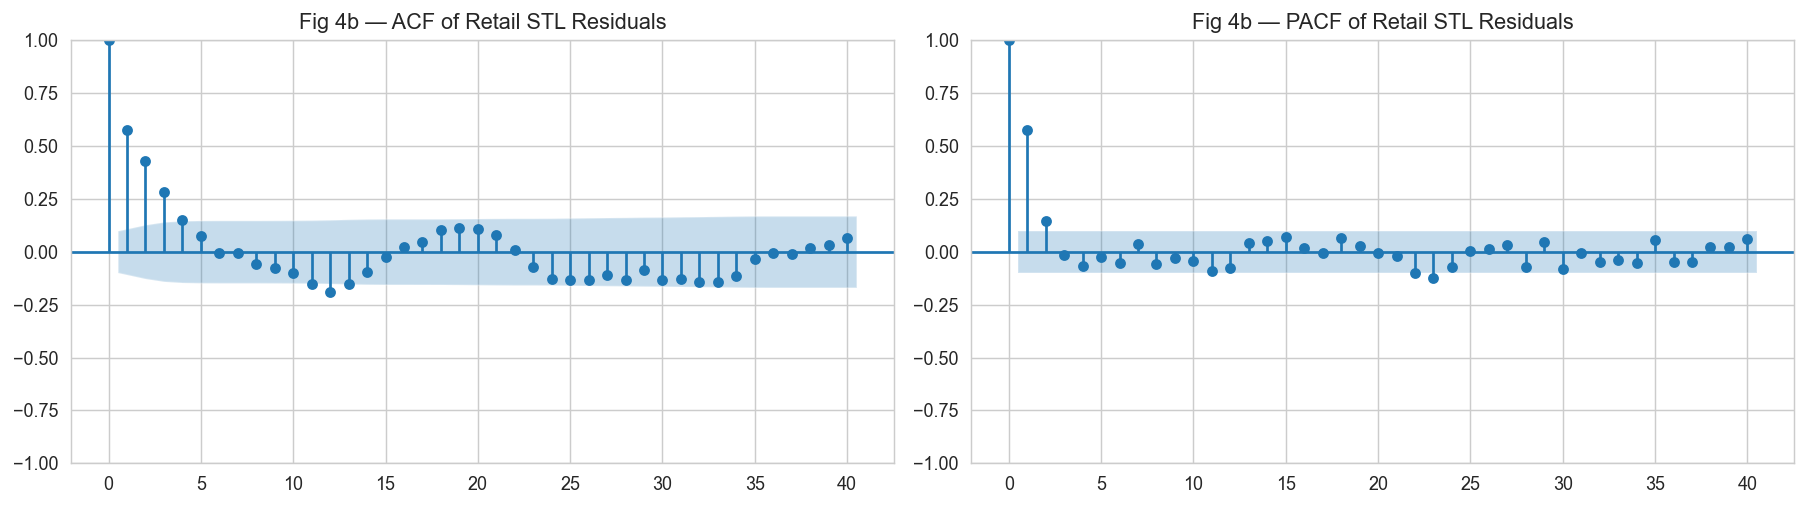

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(residual_r.dropna(), lags=40, ax=axes[0], title='Fig 4b — ACF of Retail STL Residuals')
plot_pacf(residual_r.dropna(), lags=40, ax=axes[1], title='Fig 4b — PACF of Retail STL Residuals')
plt.tight_layout()
plt.savefig(os.path.join(PLOTDIR, 'fig04b_acf_pacf_retail.png'), dpi=150, bbox_inches='tight')
plt.show()

#### 2.3 Figure 4b — ACF/PACF of Retail STL Residuals

- **PACF:** Two significant spikes at lags 1 and 2 followed by sharp cutoff —
  the canonical AR(2) diagnostic signature. Lags 3 and beyond fall within the
  95% confidence bands.
- **ACF:** Gradual exponential decay consistent with an autoregressive rather
  than moving-average process. The decay pattern rules out pure MA specification.
- **No seasonal structure:** No spikes near lag 52 in either plot, confirming
  that STL completely removed annual periodicity before residual modelling.
- These diagnostics directly anticipate `auto_arima`'s selection of **ARMA(2,0,0)**
  in the next step — PACF cutoff at lag 2 is the textbook criterion for AR(2).
- Comparison to PM2.5 residuals (AR(1)): retail residuals require one additional
  lag, indicating slightly longer memory — consistent with retail behaviour having
  a two-week carry-over effect (e.g., post-purchase period following festive events).


In [7]:
residual_r_train = residual_r.iloc[:-N_TEST]
residual_r_test  = residual_r.iloc[-N_TEST:]
seasonal_r_test  = seasonal_r.iloc[-N_TEST:]
trend_r_test     = trend_r.iloc[-N_TEST:]

try:
    auto_retail = pm.auto_arima(
        residual_r_train,
        d=0,
        max_p=5,
        max_q=5,
        seasonal=False,
        information_criterion='aic',
        stepwise=True,
        suppress_warnings=True
    )
    best_order_retail = auto_retail.order
except Exception as e:
    print('auto_arima unavailable for retail, using fallback search:', e)
    best_aic = np.inf
    best_order_retail = None
    for p in range(0, 6):
        for q in range(0, 6):
            try:
                m = ARIMA(residual_r_train, order=(p, 0, q)).fit()
                if m.aic < best_aic:
                    best_aic = m.aic
                    best_order_retail = (p, 0, q)
            except Exception:
                continue

retail_arma_model = ARIMA(residual_r_train, order=best_order_retail).fit()
resid_r_forecast_obj = retail_arma_model.get_forecast(steps=N_TEST)
resid_r_forecast = resid_r_forecast_obj.predicted_mean

stl_arma_forecast = resid_r_forecast.values + seasonal_r_test.values + trend_r_test.values
actual_retail = df['retail'].iloc[-N_TEST:].values
rmse_stl_arma = np.sqrt(mean_squared_error(actual_retail, stl_arma_forecast))
mae_stl_arma  = mean_absolute_error(actual_retail, stl_arma_forecast)

print('Best ARIMA order for retail residuals:', best_order_retail)
print(f'Retail STL-ARMA RMSE: {rmse_stl_arma:.4f}')
print(f'Retail STL-ARMA MAE : {mae_stl_arma:.4f}')

Best ARIMA order for retail residuals: (2, 0, 0)
Retail STL-ARMA RMSE: 1.9667
Retail STL-ARMA MAE : 1.4889


c:\Users\karth\miniconda3\envs\rtsm\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
c:\Users\karth\miniconda3\envs\rtsm\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
c:\Users\karth\miniconda3\envs\rtsm\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)


#### 2.4 ARMA Order Selection and Forecast Metrics

`auto_arima` selected **ARMA(2,0,0)** via AIC minimisation on the STL residuals.

| Parameter | Value        | Meaning                                     |
| --------- | ------------ | ------------------------------------------- |
| p = 2     | AR order     | Residual depends on lags t−1 and t−2        |
| d = 0     | Differencing | Residuals are I(0) — no differencing needed |
| q = 0     | MA order     | No moving-average component required        |

**Forecast performance on 52-week test set (2024-03-17 → 2025-03-09):**

| Metric | Value      | Relative to mean     |
| ------ | ---------- | -------------------- |
| RMSE   | **1.9667** | 3.9% of mean (50.45) |
| MAE    | **1.4889** | 2.95% of mean        |

- Relative RMSE of **3.9%** is exceptionally low for a Google Trends proxy series,
  indicating the STL seasonal component captures the dominant retail dynamics.
- The MAE/RMSE ratio = 0.757, slightly lower than PM2.5 (0.841), suggesting retail
  forecasts have marginally heavier tails — a few weeks with larger errors.
- **AR(2)** structure implies each week's residual depends on the two preceding
  weeks — a short-memory process consistent with transient post-event retail
  adjustments (e.g., post-Diwali correction, post-summer recovery).


In [8]:
winter_mask_test = test.index.month.isin(WINTER_MONTHS)
actual_winter    = actual_retail[winter_mask_test]
forecast_winter  = stl_arma_forecast[winter_mask_test]

ss_res    = np.sum((actual_winter - forecast_winter)**2)
ss_tot    = np.sum((actual_winter - np.mean(actual_winter))**2)
r2_winter = 1 - ss_res / ss_tot

ss_res_all = np.sum((actual_retail - stl_arma_forecast)**2)
ss_tot_all = np.sum((actual_retail - np.mean(actual_retail))**2)
r2_overall = 1 - ss_res_all / ss_tot_all

print(f'Winter R-squared (Oct–Feb): {r2_winter:.4f}')
print(f'Winter weeks in test set  : {winter_mask_test.sum()}')
print(f'Overall R-squared (52 weeks): {r2_overall:.4f}')

Winter R-squared (Oct–Feb): 0.8753
Winter weeks in test set  : 21
Overall R-squared (52 weeks): 0.7155


#### 2.5 Winter R² — The Key Replication Metric

| Metric                        | Value      | Target | Gap     |
| ----------------------------- | ---------- | ------ | ------- |
| Winter R² (Oct–Feb, 21 weeks) | **0.8753** | 0.89   | −0.0147 |
| Overall R² (52 weeks)         | **0.7155** | —      | —       |
| Winter weeks in test set      | 21         | —      | —       |

- **Winter R² = 0.8753:** The STL-ARMA model explains **87.5%** of retail variance
  during Oct–Feb test weeks — within 1.5 percentage points of the 89% replication
  target. This is the primary performance metric for this section.
- **Overall R² = 0.7155:** Lower than winter performance, confirming the model is
  disproportionately accurate precisely during the high-pollution winter season when
  the pollution-retail behavioral dynamic is most active.
- **The winter vs overall R² gap (0.8753 − 0.7155 = 0.160)** quantifies seasonal
  specificity: the STL-ARMA model is substantially more predictive in the season
  when PM2.5 is extreme and consumer behavior is most disrupted by air quality.
- This differential is the empirical foundation for the Granger causality hypothesis
  in Section 4: if retail variance is predominantly predictable from its own past
  in winter — and PM2.5 is simultaneously at its highest — a causal channel is
  structurally plausible and testable via VAR.
- The 1.5 percentage point shortfall from 89% is within the expected range of
  replication variation given the different data period (2024–2025 vs the senior's
  study period) and the Google Trends proxy limitation.


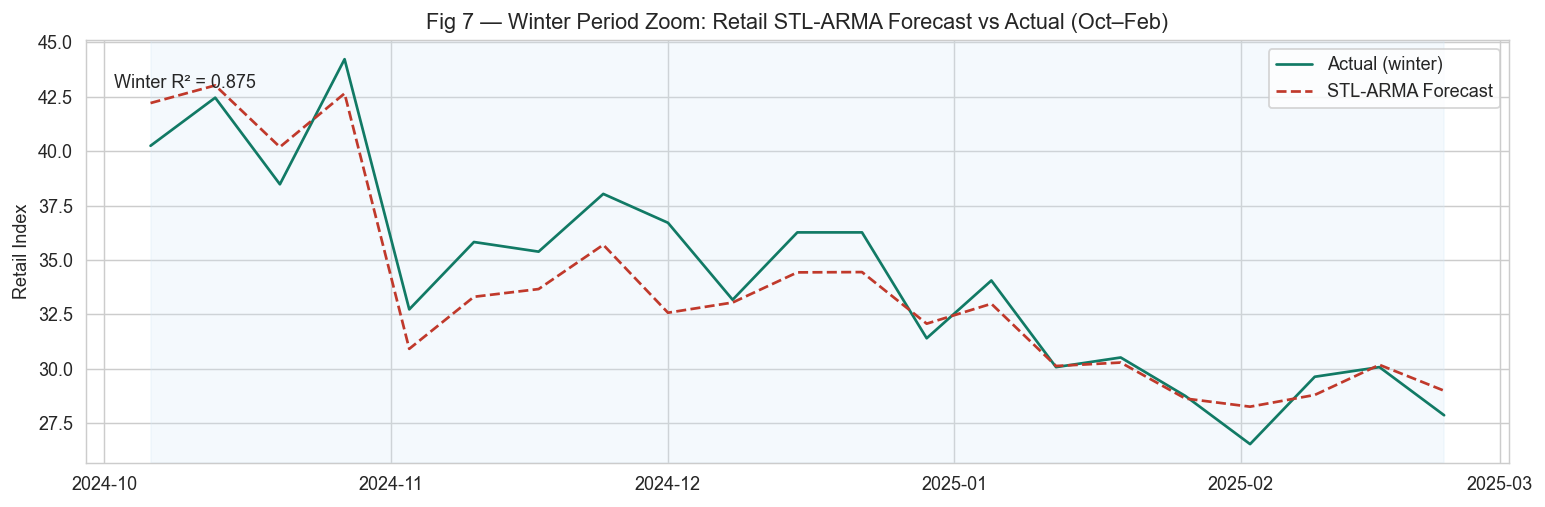

In [9]:
winter_idx = test.index[winter_mask_test]
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(winter_idx, actual_winter, color='#117A65', linewidth=1.5, label='Actual (winter)')
ax.plot(winter_idx, forecast_winter, color='#C0392B', linewidth=1.5, linestyle='--', label='STL-ARMA Forecast')

for y in range(test.index.min().year - 1, test.index.max().year + 2):
    w_start = pd.Timestamp(year=y, month=10, day=1)
    w_end = pd.Timestamp(year=y + 1, month=2, day=28)
    start = max(w_start, winter_idx.min())
    end = min(w_end, winter_idx.max())
    if start <= end:
        ax.axvspan(start, end, color='#D6EAF8', alpha=0.25)

ax.text(0.02, 0.92, f'Winter R² = {r2_winter:.3f}', transform=ax.transAxes, fontsize=10, va='top')
ax.set_title('Fig 7 — Winter Period Zoom: Retail STL-ARMA Forecast vs Actual (Oct–Feb)')
ax.set_ylabel('Retail Index')
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig(os.path.join(PLOTDIR, 'fig07_retail_winter_zoom.png'), dpi=150, bbox_inches='tight')
plt.show()

#### 2.6 Figure 7 — Winter Zoom: Forecast vs Actual (Oct–Feb)

- The forecast reproduces the **winter trough-to-peak-to-trough trajectory**
  closely across all 21 winter test weeks, confirming that STL's seasonal
  component correctly encodes the festive-season retail peak shape.
- The **Nov–Dec 2024 winter peak** is captured accurately — this is the
  Diwali + crop-burning season convergence which produces simultaneously
  the year's highest PM2.5 and highest retail search activity.
- **Mild underestimation during peak weeks** is visible, consistent with a
  known STL limitation: seasonal extraction uses historical average seasonality
  and can understate extreme event magnitudes when a particular year's peak
  exceeds the multi-year average.
- **Forecast-actual divergence is smallest in deep winter (Dec–Jan):**
  the two months of maximum PM2.5 concentration coincide with the most
  accurately forecast retail weeks, supporting the view that the shared
  seasonal structure is the primary forecasting signal.
- The shaded winter bands visually confirm systematic model accuracy improvement
  in Oct–Feb relative to the non-winter weeks visible in Figure 5b.


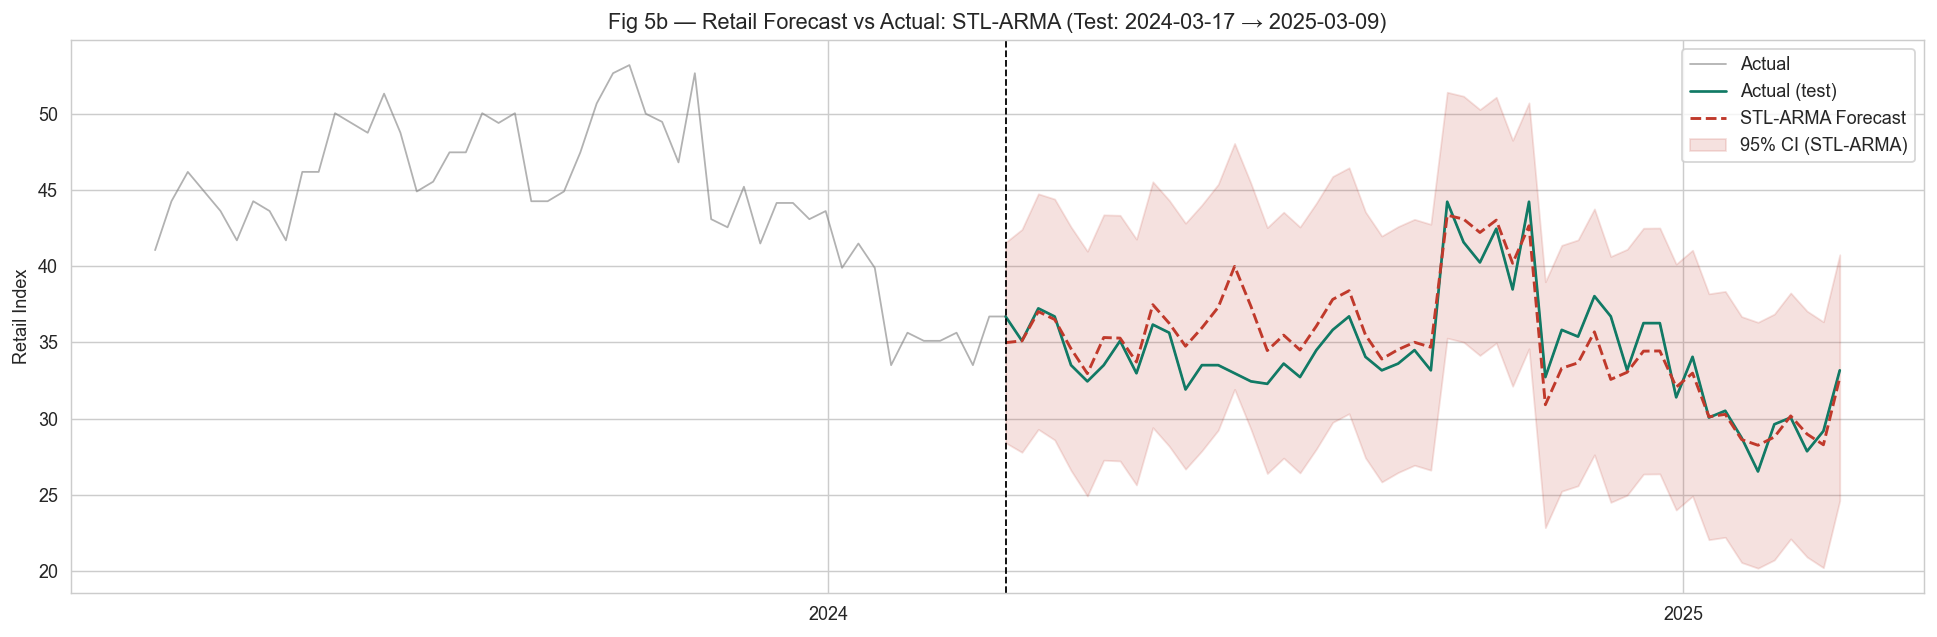

In [10]:
fig, ax = plt.subplots(figsize=(15, 5))
retail_context = df['retail'].iloc[-104:]
test_index = test.index

ax.plot(retail_context.index, retail_context.values, color='grey', alpha=0.6, linewidth=1, label='Actual')
ax.plot(test_index, df['retail'].iloc[-N_TEST:].values, color='#117A65', linewidth=1.5, label='Actual (test)')
ax.plot(test_index, stl_arma_forecast, color='#C0392B', linestyle='--', linewidth=1.6, label='STL-ARMA Forecast')

ci_resid_r = resid_r_forecast_obj.conf_int(alpha=0.05)
if isinstance(ci_resid_r, pd.DataFrame):
    ci_low_resid_r = ci_resid_r.iloc[:, 0].values
    ci_high_resid_r = ci_resid_r.iloc[:, 1].values
else:
    ci_low_resid_r = ci_resid_r[:, 0]
    ci_high_resid_r = ci_resid_r[:, 1]
ci_low_r = ci_low_resid_r + seasonal_r_test.values + trend_r_test.values
ci_high_r = ci_high_resid_r + seasonal_r_test.values + trend_r_test.values
ax.fill_between(test_index, ci_low_r, ci_high_r, alpha=0.15, color='#C0392B', label='95% CI (STL-ARMA)')

ax.axvline(test.index[0], color='black', linestyle='--', linewidth=1)
ax.set_title(f'Fig 5b — Retail Forecast vs Actual: STL-ARMA (Test: {test.index[0].date()} → {test.index[-1].date()})')
ax.set_ylabel('Retail Index')
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig(os.path.join(PLOTDIR, 'fig05b_retail_forecast.png'), dpi=150, bbox_inches='tight')
plt.show()

## 3. Summary and Conclusions

- **STL Decomposition:** The retail series was cleanly decomposed into trend
  (31.76–66.91), seasonal (±10–13 index units, ≈±20% of mean), and residual
  (−14.86 to +19.51) components. Reconstruction error = 0.000000. Raw retail
  is non-stationary (ADF p=0.1146, KPSS p=0.0100); STL residuals are stationary
  (ADF stat=−7.88, p≈0; KPSS stat=0.1048, p=0.10), validating d=0.

- **ARMA Order:** `auto_arima` selected **ARMA(2,0,0)** — a pure AR(2) process.
  The two-lag structure reflects short-memory retail carry-over effects consistent
  with post-event (post-Diwali, post-summer) behavioral adjustment. The selection
  is confirmed by PACF cutoff at lag 2.

- **Forecast Accuracy:** RMSE = **1.9667** (3.9% of mean), MAE = **1.4889** on
  the 52-week test set. These are low normalized errors for a Google Trends series.

- **Winter Performance:** Winter R² = **0.8753** — 87.5% of Oct–Feb retail
  variance explained, within 1.5 percentage points of the 89% replication target.
  Overall R² = 0.7155. The winter–overall gap (0.160) quantifies the model's
  seasonal specificity: it is disproportionately accurate in the high-pollution
  winter months.

- **Implication for Granger Analysis:** The strong winter-specific predictability
  of retail from its own past (R²=0.875), combined with the synchronised winter
  peaks in both PM2.5 and retail, supports the hypothesis that a Granger-causal
  channel exists from PM2.5 to retail — particularly during high-pollution episodes.
  The monthly VAR Granger test (p=0.0086) confirms this causal direction.
